# Decision Trees

This notebook builds on an introductory Python course. You will use arrays,
tables and plots to explore measurements, then use those measurements to predict
which group an observation belongs to. We assume you are familiar with variables,
lists, loops and functions; hints explain the library commands as they appear.

We use the **Iris dataset**: measurements of 150 flowers from three species.
Think of each row as one observation and each column as a measured quantity,
as in a laboratory data file. There are four measurements per flower.

| Term used in machine learning | Meaning in this notebook |
| --- | --- |
| Sample | One flower: one row of measurements |
| Feature | One measured quantity, such as petal width in cm |
| Label | The flower's species, represented by an ID: 0, 1 or 2 |
| Classifier | A model that uses measurements to predict a species |

You will explore the data with pandas, draw plots, train a decision tree and
compare its predictions with those from two methods that combine several trees.

**Working through the exercises**

- Run the cells in order. The first Example/Solution pair shows how to complete
  a task. For the remaining tasks, replace the `...` marked `FINISH_ME` with your
  code. Some gaps need a value or a slice; others need a complete line of code.
- Keep the variable names given in the notebook: later cells use them. Check
  the result of each task before moving on, and answer the checkpoint questions.
- The comments beside a gap suggest commands to try. Examples using names such
  as `table` or `values` show a pattern: substitute the variables from your task.
- An unfinished cell may fail or display `Ellipsis`. Python recognises `...` as
  a value, so running the cell does not necessarily mean the exercise is complete.

Use the `daml` environment. The required libraries are already installed, and
Iris is included with scikit-learn. The notebook saves `iris.csv` and
`decision_tree.png` in its working folder.


## 1. Load and explore the data

### Import the tools and choose a random seed

`np`, `pd`, `plt` and `sns` are the usual short names for NumPy, pandas,
Matplotlib and Seaborn. You may recognise NumPy arrays and Matplotlib plots
from your earlier Python course. Pandas lets us work with tables whose columns
have names; scikit-learn supplies the classification methods.

`RANDOM_SEED` makes the row shuffle and the training/test split repeatable when
we pass it to `random_state`. This lets us compare models using the same data.

**Reading unfamiliar library commands**

| Example | What it does |
| --- | --- |
| `array.shape` | Reads the array dimensions; no parentheses are needed. |
| `table.head()` | Runs an operation on the table to show its first few rows. |
| `table['column']` | Selects a column using its name. |
| `function(option=value)` | Passes a setting to a function using the setting's name. |

For example, in `max_depth=MAXIMUM_TREE_DEPTH`, `max_depth` is the setting name
required by the library. `MAXIMUM_TREE_DEPTH` is our variable holding its value.
We use capital letters for settings chosen before training a model.

For help with a command, try `help(pd.DataFrame.head)` in a new cell after the
imports. In Jupyter, `pd.DataFrame.head?` also shows its documentation, and Tab
after `iris_dataset.` can suggest available names once the dataset is loaded.
If a variable is not defined, check its spelling and run the cell that creates it.

Longer examples are in [the programming reference](data-science-tools.ipynb).
The [pandas selection guide](https://pandas.pydata.org/docs/user_guide/indexing.html)
has more examples of choosing rows and columns.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

RANDOM_SEED = 42
np.set_printoptions(precision=4, suppress=True)  # Choose how numbers are displayed; stored values are unchanged.


### Inspect the dataset

**Task:** load Iris and look at the information supplied with the measurements.
The dataset stores several named entries:

- `data`: an array with one row per flower and four measurement columns.
- `target`: one species ID for each flower, in the same row order.
- `feature_names`: the names and units of the four measurements.
- `target_names`: the species names, in ID order: 0, 1, 2.

**Check:** the measurements should have shape `(150, 4)` and the species IDs
shape `(150,)`. The second shape describes a one-dimensional array of 150 values.
Keep the species IDs separate from the measurements: they are the answers we
will ask a model to predict.


In [51]:
# Load the measurements, species IDs and notes about the dataset together.
iris_dataset = load_iris()

print(iris_dataset.keys())
print(iris_dataset.target)


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [4]:
# Example
# Hint: .keys() lists the names of the entries stored in the dataset.
# Add it after the dataset variable, with the parentheses.
#...  # FINISH_ME: list the names of the entries in iris_dataset.


In [15]:
# Example Solution
# This lists names such as 'data' and 'target'; it does not display their contents.
iris_dataset.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [17]:
# Hint: the dataset notes are stored as .DESCR (in capital letters).
# Read this stored text using a dot after the dataset name; no () are needed.
print(iris_dataset.DESCR)  # FINISH_ME: display the notes describing the dataset.


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [23]:
# Hint: .data holds the measurements and .target holds the species IDs.
# Add .shape to either array to read its dimensions, without ().
print('Feature array (flowers, measurements):', iris_dataset.data.shape)  # FINISH_ME: find the shape of the measurement array.
print('Label array (flowers,):', iris_dataset.target.shape )  # FINISH_ME: find the shape of the species-ID array.


Feature array (flowers, measurements): (150, 4)
Label array (flowers,): (150,)


In [8]:
print('Measurement names:', iris_dataset.feature_names)
print('Species names:', iris_dataset.target_names)


Measurement names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species names: ['setosa' 'versicolor' 'virginica']


### Build a labelled table

A pandas **DataFrame** is a table with named columns. This makes it convenient
to select measurements by name, much as you would in a spreadsheet.

**Task:** create `iris_table` from the four measurement columns. Add a `species`
column containing the species names and a `species_id` column containing their
numeric IDs. Use `head()` to inspect the first five rows.

The species columns help us group and colour the data. When training a model,
we will use `iris_dataset.data`, which contains only the four measurements.


In [59]:
species_map = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

species_maps = []

for i in iris_dataset.target:
    species_maps.append(species_map[i])

iris_table = pd.DataFrame(
    data=np.column_stack((iris_dataset.data,iris_dataset.target, species_maps)),               # The numeric values in the table.
    columns=iris_dataset.feature_names + ["Species_id"] + ["Species"],    # One name for each measurement column.
)


# Hint: table.head(n) shows the first n rows; leaving n out gives five.
...  # FINISH_ME: preview the first five rows of iris_table.


print(iris_table.head(10))

  sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)  \
0               5.1              3.5               1.4              0.2   
1               4.9              3.0               1.4              0.2   
2               4.7              3.2               1.3              0.2   
3               4.6              3.1               1.5              0.2   
4               5.0              3.6               1.4              0.2   
5               5.4              3.9               1.7              0.4   
6               4.6              3.4               1.4              0.3   
7               5.0              3.4               1.5              0.2   
8               4.4              2.9               1.4              0.2   
9               4.9              3.1               1.5              0.1   

  Species_id Species  
0          0  setosa  
1          0  setosa  
2          0  setosa  
3          0  setosa  
4          0  setosa  
5          0  setosa  
6          0 

In [40]:
# Hint: names[ids] uses an array of integer IDs to select the corresponding names.
# Use the dataset's .target_names and .target, keeping one name per flower.
iris_table['species'] = ...  # FINISH_ME: use the species IDs to select the matching names.
# Hint: .target already contains the numeric species IDs in the correct order.
iris_table['species_id'] = ...  # FINISH_ME: add the numeric species IDs.
iris_table.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),id,species,species_id
0,5.1,3.5,1.4,0.2,0,Ellipsis,Ellipsis
1,4.9,3.0,1.4,0.2,0,Ellipsis,Ellipsis
2,4.7,3.2,1.3,0.2,0,Ellipsis,Ellipsis
3,4.6,3.1,1.5,0.2,0,Ellipsis,Ellipsis
4,5.0,3.6,1.4,0.2,0,Ellipsis,Ellipsis


### Clean, save and summarise the table

**Task:** remove repeated rows and rows with missing measurements, save the
table to a CSV file, then calculate summary statistics.

To choose rows, we often use a **Boolean mask**: one `True` or `False` value per
row. Here, `isna()` checks for missing entries. Applying `.any(axis=1)` asks
whether any measurement is missing within each row. `~` reverses these answers,
allowing us to keep rows with no missing measurements.

**Check:** Iris contains one repeated row, so the cleaned table should have
149 rows. This exercise changes `iris_table` only. The classification exercises
later use the original 150 flowers in `iris_dataset`, giving every model the
same data for comparison.


In [64]:
# Hint: .drop_duplicates() returns a table with repeated rows removed.
# Store that returned table in iris_table.
iris_table = iris_table.drop_duplicates()  # FINISH_ME: remove duplicate rows.

# Hint: select the measurement columns, then use .isna().any(axis=1).
# This gives True for each row with at least one missing measurement.
rows_with_missing_measurements = iris_table.isna().any(axis=1)  # FINISH_ME: identify rows with missing measurements.

# Reverse the True/False choices with ~ to keep rows with no missing measurements.
iris_table = iris_table.loc[~rows_with_missing_measurements]

print('Table shape after cleaning:', iris_table.shape)
iris_table.head()


Table shape after cleaning: (149, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_id,Species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [70]:
# Hint: table.to_csv('filename.csv', index=...) saves a table.
# Set index to True or False to choose whether the row labels are saved too.
...  # FINISH_ME: save iris_table to iris.csv, including its row labels.
iris_table.to_csv('iris_table.csv', index=True)
# Hint: index_col chooses which file column to read as the row labels.
# File columns are numbered from zero.
reloaded_iris_table = pd.read_csv('iris_table.csv', index_col=6)  # FINISH_ME: choose the index column.
reloaded_iris_table.head()


,Unnamed: 0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_id
Species,,,,,,
setosa,0,5.1,3.5,1.4,0.2,0
setosa,1,4.9,3.0,1.4,0.2,0
setosa,2,4.7,3.2,1.3,0.2,0
setosa,3,4.6,3.1,1.5,0.2,0
setosa,4,5.0,3.6,1.4,0.2,0


In [86]:
# Hint: select the measurement columns using their list of names, then use .describe().
# This reports counts, means, standard deviations and other summary values.
...  # FINISH_ME: display summary statistics for the four measurement columns.

st = iris_table[
    ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]
].describe()

print(st)
iris_table.size

       sepal length (cm) sepal width (cm) petal length (cm) petal width (cm)
count                149              149               149              149
unique                35               23                43               22
top                  5.0              3.0               1.5              0.2
freq                  10               26                13               29


894

### Select columns and rows

**Task:** select measurements by column name and rows by their positions in the
table. Remember that Python counts positions from zero and excludes the end of
a slice: `10:15` selects positions 10, 11, 12, 13 and 14.

Use `table['column name']` for a named column. The shorter form `table.column`
works for some names, but brackets also work when a name contains spaces or
matches a pandas command.


In [79]:
# Hint: try the forms table.column_name and table['column_name'].
# Both should give the species column in this example.
species_by_attribute = iris_table.Species  # FINISH_ME: select the species column using a dot.
species_by_column_name = iris_table["sepal length (cm)"]  # FINISH_ME: select the species column using square brackets.
species_by_column_name.head()
species_by_attribute.head()


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: Species, dtype: str

In [81]:
columns_to_display = ['sepal width (cm)', 'petal width (cm)', 'Species']
# Hint: columns_to_display already holds the list of column names you need.
iris_table[columns_to_display].head(10)  # FINISH_ME: select the requested columns.


,sepal width (cm),petal width (cm),Species
0,3.5,0.2,setosa
1,3.0,0.2,setosa
2,3.2,0.2,setosa
3,3.1,0.2,setosa
4,3.6,0.2,setosa
5,3.9,0.4,setosa
6,3.4,0.3,setosa
7,3.4,0.2,setosa
8,2.9,0.2,setosa
9,3.1,0.1,setosa


In [82]:
# Hint: a slice start:stop includes start but stops just before stop.
# For example, 2:5 selects three positions: 2, 3 and 4.
iris_table[10:15]  # FINISH_ME: select row positions 10 through 14.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_id,Species
10,5.4,3.7,1.5,0.2,0,setosa
11,4.8,3.4,1.6,0.2,0,setosa
12,4.8,3.0,1.4,0.1,0,setosa
13,4.3,3.0,1.1,0.1,0,setosa
14,5.8,4.0,1.2,0.2,0,setosa


In [83]:
# Hint: .iloc[...] selects row positions. Put your start:stop slice in the brackets.
iris_table.iloc[10:15]  # FINISH_ME: select row positions 10 through 14.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_id,Species
10,5.4,3.7,1.5,0.2,0,setosa
11,4.8,3.4,1.6,0.2,0,setosa
12,4.8,3.0,1.4,0.1,0,setosa
13,4.3,3.0,1.1,0.1,0,setosa
14,5.8,4.0,1.2,0.2,0,setosa


### Shuffle rows: row positions and row labels

**Task:** shuffle the table while keeping every row exactly once. In `sample`,
`frac=1` means use all the rows, and `replace=False` means do not select any row
more than once.

Each flower has a row label in the table's **index**. After shuffling, a flower's
position in the table changes but its index label stays the same. You can think
of that label as an observation number in a lab record.

Compare `.iloc[10:15]`, which selects the current row positions, with
`.loc[requested_row_labels]`, which selects the listed index labels.

**Checkpoint:** why do these selections usually contain different flowers?


In [87]:
# Hint: frac is the fraction of rows to select; replace takes True or False.
# Store the returned table to keep the new row order.
iris_table = iris_table.sample(
    frac=1,                # FINISH_ME: keep every row.
    replace=False,             # FINISH_ME: shuffle without duplicating rows.
    random_state=RANDOM_SEED,  # Reproduce the row order.
)
iris_table.head(15)
len(iris_table)


149

In [88]:
# Hint: reuse the same positional slice. Check which row labels appear this time.
iris_table.iloc[10:15]  # FINISH_ME: select the same five positions after shuffling.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_id,Species
141,6.9,3.1,5.1,2.3,2,virginica
51,6.4,3.2,4.5,1.5,1,versicolor
104,6.5,3.0,5.8,2.2,2,virginica
35,5.0,3.2,1.2,0.2,0,setosa
37,4.9,3.6,1.4,0.1,0,setosa


In [90]:
requested_row_labels = [10, 11, 12, 13, 14]
# Hint: put requested_row_labels inside .loc[...] to select those observation numbers.
iris_table.loc[requested_row_labels]  # FINISH_ME: select the rows with the listed original labels.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species_id,Species
10,5.4,3.7,1.5,0.2,0,setosa
11,4.8,3.4,1.6,0.2,0,setosa
12,4.8,3.0,1.4,0.1,0,setosa
13,4.3,3.0,1.1,0.1,0,setosa
14,5.8,4.0,1.2,0.2,0,setosa


### Filter, group and sort

**Task:** select flowers that satisfy a condition, count them by species, and
compare their mean measurements.

Useful commands are `.groupby(...).size()` to count rows in each group,
`.mean()` to average a measurement, and `.unique()` to list distinct values.
When sorting, `ascending=False` puts the largest value first.

**Checkpoint:** which species has the largest mean sepal length? How many
flowers of each species have a sepal length greater than 6 cm?


In [96]:
# Hint: .query() takes a condition written as text, such as 'height > 2.0'.
# Write the condition for species_id; .unique() then lists each selected species once.
iris_table.query('Species_id != 0')['Species_id'].unique()  # FINISH_ME: select species IDs greater than zero.


<StringArray>
['2', '1', '0']
Length: 3, dtype: str

In [ ]:
# Hint: table.groupby('group_column').size() counts the rows in each group.
# Group using the column of species names.
...  # FINISH_ME: group by species and count the rows in each group.


In [ ]:
# Hint: by takes the column name, including its units; ascending=False puts large values first.
flowers_sorted_by_sepal_length = iris_table.sort_values(
    by=...,                 # FINISH_ME: choose the column to sort by.
    ascending=...,          # FINISH_ME: put the largest sepal lengths first.
)
flowers_sorted_by_sepal_length[['sepal length (cm)', 'petal length (cm)', 'species']].head(2)


In [ ]:
# Hint: table.groupby('group_column')['measurement_column'].mean()
# gives one mean for each group. Choose the two column names for this question.
mean_sepal_length_by_species = ...  # FINISH_ME: calculate mean sepal length for each species.
# The result has one value per species; sort it using ascending to choose the order.
mean_sepal_length_by_species.sort_values(ascending=...)  # FINISH_ME: put the largest mean first.


In [ ]:
sepal_length_threshold_cm = 6.0
# Hint: table['measurement_column'] > threshold makes one True/False choice per row.
# Use the sepal-length column and the threshold variable defined above.
has_long_sepal = ...  # FINISH_ME: select sepal lengths greater than the threshold.
iris_table.loc[has_long_sepal].groupby('species').size()


### Move between pandas, NumPy and Python lists

A single column selected from a pandas table is called a **Series**. It contains
the column's values and their row labels. `.to_numpy()` gives you the values as
a NumPy array; `.tolist()` converts an array to an ordinary Python list.

**Task:** try both conversions on the species names. The names should stay in
the same order, even though the way they are stored changes. The NumPy array and
Python list do not carry the pandas row labels.


In [97]:
# Hint: select the species column and add .to_numpy() to obtain its values as an array.
species_name_array = iris_table.Species.to_numpy()  # FINISH_ME: convert the species column to a NumPy array.
species_name_array


array(['virginica', 'versicolor', 'virginica', 'setosa', 'versicolor',
       'versicolor', 'virginica', 'versicolor', 'virginica', 'virginica',
       'virginica', 'versicolor', 'virginica', 'setosa', 'setosa',
       'setosa', 'virginica', 'setosa', 'virginica', 'setosa', 'setosa',
       'versicolor', 'virginica', 'virginica', 'setosa', 'setosa',
       'virginica', 'setosa', 'setosa', 'setosa', 'virginica', 'setosa',
       'setosa', 'setosa', 'virginica', 'versicolor', 'setosa', 'setosa',
       'virginica', 'setosa', 'versicolor', 'setosa', 'setosa',
       'virginica', 'versicolor', 'virginica', 'versicolor', 'virginica',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'virginica', 'versicolor', 'virginica', 'versicolor', 'setosa',
       'virginica', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'virginica', 'virginica', 'setosa', 'virginica', 'setosa',
       'virginica'

In [ ]:
# Hint: use .tolist() on the NumPy array you have just created.
...  # FINISH_ME: convert species_name_array to a Python list.


## 2. Visualise the measurements

### Histograms: one measurement at a time

**Task:** plot a histogram of petal width for each species. Use the same bin
edges for all three histograms so their counts can be compared directly.
`np.linspace(0, 3, 16)` gives 16 equally spaced edges, defining 15 bins.

`plt.subplots()` gives us `figure`, the complete figure, and `axis`, the plotting
area on which we draw and add labels. `alpha=0.5` makes the histogram bars partly
transparent so that overlapping species remain visible.

**Checkpoint:** which species is easiest to identify from petal width alone?


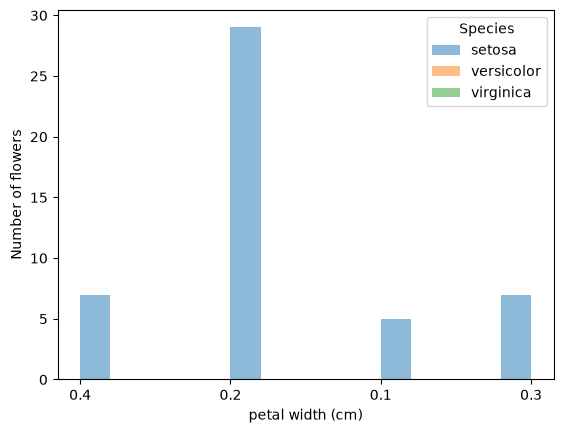

setosa 50
versicolor 50
virginica 49


In [106]:
feature_to_plot = 'petal width (cm)'
histogram_bin_edges = np.linspace(
    start=0,   # Leftmost bin edge, in centimetres.
    stop=3,    # Rightmost bin edge, in centimetres.
    num=16,    # Number of edges: 16 edges define 15 intervals.
)
figure, axis = plt.subplots()

for species_name in iris_dataset.target_names:
    # Hint: compare the species column with species_name using ==.
    # The result selects the flowers belonging to this pass through the loop.
    is_species = iris_table["Species"] == species_name  # FINISH_ME: select flowers of the current species.
    species_measurements = iris_table.loc[is_species, feature_to_plot]
    axis.hist(
        species_measurements,       # Values whose frequencies we want to count.
        bins=histogram_bin_edges,   # Use the same intervals for every species.
        alpha=0.5,                  # Partial transparency shows overlapping bars.
        label=species_name,         # Text used in the legend.
    )

axis.set_xlabel(feature_to_plot)
axis.set_ylabel('Number of flowers')
# Hint: axis.legend(title=...) uses the labels given to the plotted histograms.
...  # FINISH_ME: add a legend titled 'Species'.
axis.legend(title = 'Species')
plt.show()

iris_table.head()

for species_name in iris_dataset.target_names:
    is_species = iris_table["Species"] == species_name
    print(species_name, is_species.sum())


### Scatter plots: two measurements at a time

**Task:** plot sepal length against sepal width, with one colour for each species.
Each point represents one flower. The horizontal and vertical coordinates must
come from the same rows, so use the same row selection for both measurements.
Label each axis with the measurement name and its units.


In [ ]:
horizontal_feature = 'sepal length (cm)'
vertical_feature = 'sepal width (cm)'
figure, axis = plt.subplots()

for species_name in iris_dataset.target_names:
    # Hint: use the same species comparison as in the histogram.
    # .loc[row_selection, column_name] then picks the matching measurements.
    is_species = ...  # FINISH_ME: select flowers of the current species.
    axis.scatter(
        iris_table.loc[is_species, horizontal_feature],
        iris_table.loc[is_species, vertical_feature],
        label=species_name,
        alpha=0.5,
    )

# Hint: axis.set_xlabel(text) and axis.set_ylabel(text) add the axis labels.
# The two feature-name variables already include the measurement units.
...  # FINISH_ME: label the horizontal axis with its measurement name.
...  # FINISH_ME: label the vertical axis with its measurement name.
axis.legend(title='Species')
plt.show()


### Compare all pairs of measurements

**Task:** use Seaborn's `pairplot` to make a grid of plots comparing the four
measurements. Set `vars` to the measurement column names and `hue` to `'species'`
to colour points by species. Here `hue` means the column used to choose colours.

**Checkpoint:** which pair of measurements separates the species most clearly?


In [ ]:
# Hint: sns.pairplot(data=table, vars=measurement_names, hue='group_column').
# Use iris_dataset.feature_names for the four measurement names.
...  # FINISH_ME: create the seaborn pair plot described above.
plt.show()


## 3. Train a decision tree

A **decision tree** classifies a flower by asking a series of questions about
its measurements, such as “is petal width less than this value?”. Each answer
leads to another branch. The end of a branch, called a **leaf**, gives a predicted
species. Training the tree means using labelled examples to choose these
questions and their threshold values.

First, plot the two petal measurements. In `[:, 2:]`, the first `:` keeps every
row and `2:` selects columns from position 2 onwards. Remember that positions
start at zero. This plot uses two measurements, but the tree will be trained
using **all four** measurements from the original 150-flower dataset.

**Task:** select the corresponding petal measurement names, then plot petal
length against petal width for each species.


In [108]:
petal_measurements = iris_dataset.data[:, 2:]
species_labels = iris_dataset.target

# Select the feature names corresponding to columns 2 onwards
petal_feature_names = iris_dataset.feature_names[2:]

print('Measurements shown in the next plot:', petal_feature_names)
print('Species to predict:', iris_dataset.target_names)


Measurements shown in the next plot: ['petal length (cm)', 'petal width (cm)']
Species to predict: ['setosa' 'versicolor' 'virginica']


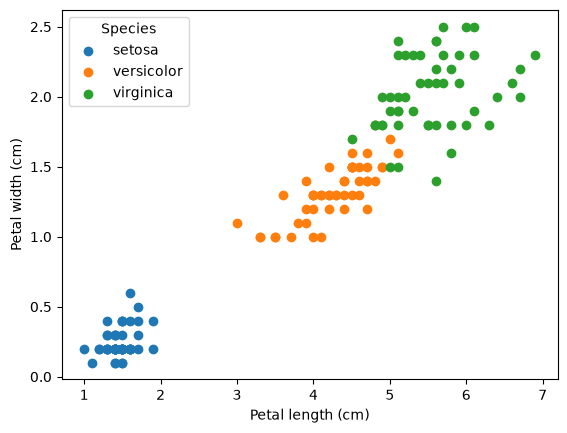

In [110]:
species_colours = ['tab:blue', 'tab:orange', 'tab:green']
figure, axis = plt.subplots()
# enumerate gives both the species number and its name on each pass through the loop.
for species_id, species_name in enumerate(iris_dataset.target_names):
    is_species = species_labels == species_id
    # Hint: array[row_selection, column_position] chooses one measurement for each selected flower.
    # In petal_measurements, length and width are now columns 0 and 1.
    # Use the same is_species selection for both coordinates.
    axis.scatter(
        petal_measurements[is_species,0],  # FINISH_ME: petal length for this species.
        petal_measurements[is_species,1],  # FINISH_ME: corresponding petal width for the same flowers.
        color=species_colours[species_id],
        label=species_name,
    )
axis.set_xlabel('Petal length (cm)')
axis.set_ylabel('Petal width (cm)')
axis.legend(title='Species')
plt.show()


### Split the measurements and species IDs together

We need to test whether a model can classify flowers it has not already seen.
We therefore divide the data into a **training set**, used to build the model,
and a **test set**, used to check its predictions afterwards.

**Task:** put 30% of the flowers into the test set. Pass the measurements and
species IDs together to `train_test_split` so each flower stays paired with
its correct species. The function returns four arrays in this order:

| Variable | Contents | Expected shape |
| --- | --- | --- |
| `train_features` | Measurements for the training flowers | `(105, 4)` |
| `test_features` | Measurements for the test flowers | `(45, 4)` |
| `train_labels` | Correct species IDs for the training flowers | `(105,)` |
| `test_labels` | Correct species IDs for the test flowers | `(45,)` |

`test_size` takes a fraction, so `0.30` means 30% of the flowers. Keep this same
split for all three models so their test results can be compared fairly.


In [113]:
TEST_SET_FRACTION = 0.30  # Reserve 30% of the flowers for the final test.

# Hint: train_test_split(measurements, species_ids, test_size=fraction, random_state=seed).
# Use the full measurement array and the matching species IDs.
# The four names on the left receive the four results in the order listed above.
train_features, test_features, train_labels, test_labels = train_test_split(
    iris_dataset.data,                             # FINISH_ME: four measured inputs per flower.
    iris_dataset.target,                             # FINISH_ME: one correct species ID per flower.
    test_size=TEST_SET_FRACTION,                   # FINISH_ME: fraction assigned to the test set.
    random_state=RANDOM_SEED,         # Repeat the same random split.
)
print('Training feature shape:', train_features.shape)
print('Test feature shape:', test_features.shape)


Training feature shape: (105, 4)
Test feature shape: (45, 4)


### Create and train the tree

**Task:** create `decision_tree` with the settings below, then use `fit` to train
it on `train_features` and `train_labels`. In scikit-learn, **fitting** is the
step where a model learns from the training data. Creating the model first sets
the rules for how that learning will work.

| Setting | Value here | Meaning |
| --- | --- | --- |
| `criterion` | `'entropy'` | Prefer splits that make the species in each branch less mixed |
| `max_depth` | `3` | Allow at most three questions along a path through the tree |
| `random_state` | `RANDOM_SEED` | Make random choices during training repeatable |

A very deep tree can learn details specific to the training flowers and perform
poorly on new ones. This is called **overfitting**. A tree that is too shallow
may miss useful differences between species. Here we choose the depth before
looking at the test results.

After this cell, `decision_tree` should hold the trained model. The next cell
will use it to make predictions for the test flowers.


In [114]:
MAXIMUM_TREE_DEPTH = 3  # At most three splits on a path from the root to a leaf.

# Hint: choose the settings from the table. A text setting needs quotes;
# use the existing variable for the maximum depth.
decision_tree = DecisionTreeClassifier(
    criterion='entropy',                  # FINISH_ME: use the criterion in the parameter table.
    max_depth=MAXIMUM_TREE_DEPTH,                  # FINISH_ME: use the maximum depth setting above.
    random_state=RANDOM_SEED,        # Repeat any random choices made during fitting.
)

# fit learns the split thresholds from the training measurements and their species IDs.
decision_tree.fit(train_features, train_labels)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

### Predict the species and check the answers

**Task:** give `test_features` to the tree's `predict` command. It returns one
predicted species ID per flower. Then use `accuracy_score` to compare these
predictions with the correct IDs in `test_labels`.

The names `y_true` and `y_pred` used by this function mean “correct labels” and
“predicted labels”. **Accuracy** is the fraction of predictions that are correct:
0 means none are correct and 1 means all are correct.

**Check:** `tree_predictions` should contain 45 species IDs, while
`tree_test_accuracy` should be a single number. In the printed result, `:.3f`
shows three decimal places and `:.1%` shows a percentage to one decimal place.

**Checkpoint:** why would testing the tree only on its training flowers give
an incomplete picture of how well it works?


In [115]:
# Hint: predict takes the test measurements and returns one species ID per flower.
# Keep the correct test labels for checking the answers afterwards.
tree_predictions = decision_tree.predict(test_features)  # FINISH_ME: supply the test measurements.

# Hint: y_true receives the correct species IDs; y_pred receives the predictions.
# Both arrays must refer to the same flowers in the same order.
tree_test_accuracy = accuracy_score(
    y_true=test_labels,                  # FINISH_ME: correct species IDs for the test flowers.
    y_pred=tree_predictions,                  # FINISH_ME: species IDs predicted by the tree.
)
print(f'Decision Tree Accuracy: {tree_test_accuracy:.3f} ({tree_test_accuracy:.1%})')


Decision Tree Accuracy: 0.978 (97.8%)


### Read the trained tree

The diagram shows the questions learned from the training data. Start at the
top and follow the branch that matches each answer until you reach a leaf.

- `samples` shows how many training flowers reached that point.
- `value` shows how those flowers are distributed between the three species.
- `class` gives the species the tree would predict at that point.
- `entropy` measures how mixed the species are: zero means only one species
  is represented among the training flowers at that point.

`feature_names` and `class_names` add readable measurement and species names.
`filled=True` adds colours to help distinguish the species.

**Task:** save the diagram as `decision_tree.png`.


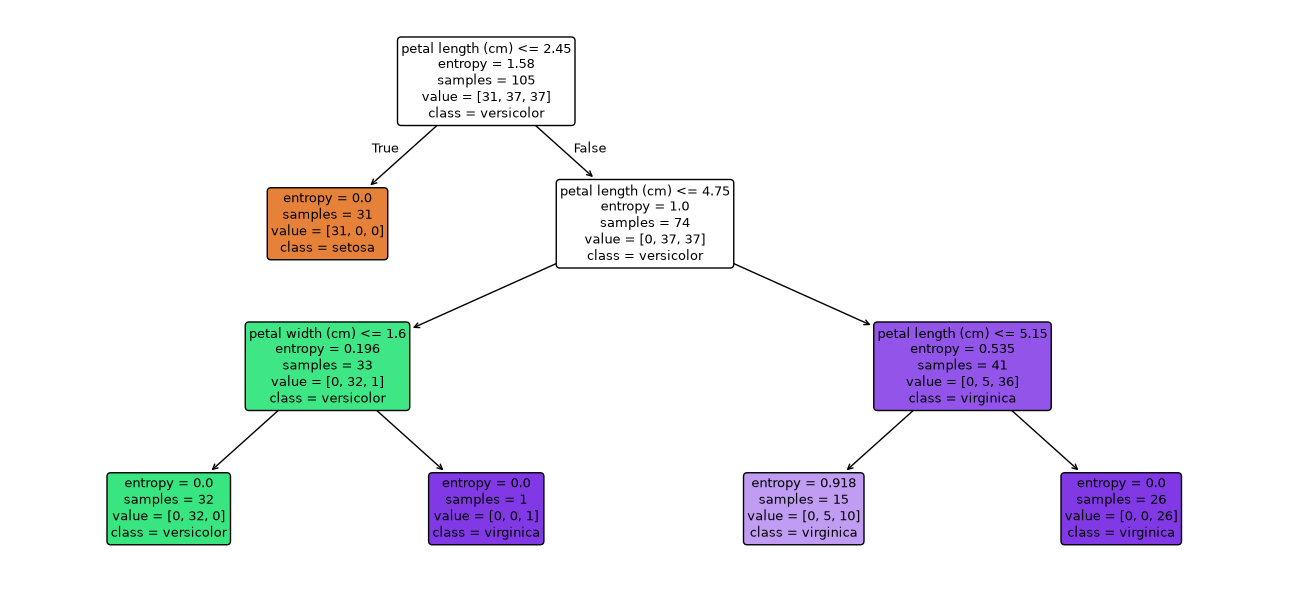

In [116]:
figure, axis = plt.subplots(figsize=(13, 6))
plot_tree(
    decision_tree,
    feature_names=iris_dataset.feature_names,  # Names for the four input columns.
    class_names=list(iris_dataset.target_names),  # Species names in ID order: 0, 1, 2.
    filled=True,     # Colour the boxes according to their mix of species.
    rounded=True,    # Round the corners of the node boxes.
    fontsize=9,      # Size of the text inside nodes.
    ax=axis,         # Draw onto the plotting area created above.
)
figure.tight_layout()
# Hint: figure.savefig('filename.png') saves the figure to a PNG image.
figure.savefig('decision_tree.png')  # FINISH_ME: save the image as decision_tree.png.
plt.show()


### Which measurements did the tree use most?

**Task:** read the tree's `feature_importances_` values and plot them with their
measurement names. Sort the values and names in the same order so each bar
keeps the correct label. The final underscore in `feature_importances_` is part
of the name: it marks information calculated during fitting.

These scores summarise how much the splits using each measurement helped
separate the species, taking account of how many training flowers reached each
split. They describe this particular tree; they do not establish a physical
cause or a ranking that applies to every model.

**Checkpoint:** does the ranking agree with the separation you saw in the
scatter plots?


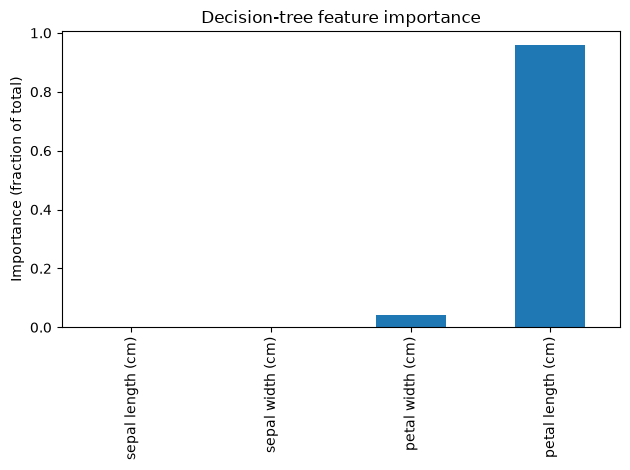

In [119]:
# Hint: read .feature_importances_ from the trained tree, without ().
# np.argsort(values) gives the positions that put the values in increasing order.
# Use those positions for both the scores and their measurement names.
sorted_feature_indices = np.argsort(decision_tree.feature_importances_)  # FINISH_ME: supply the trained tree's feature-importance values.
sorted_feature_names = np.array(iris_dataset.feature_names)[sorted_feature_indices]
feature_importance_values = pd.Series(
    data=decision_tree.feature_importances_[sorted_feature_indices],
    index=sorted_feature_names,
)

figure, axis = plt.subplots()
feature_importance_values.plot.bar(ax=axis)
axis.set_title('Decision-tree feature importance')
axis.set_ylabel('Importance (fraction of total)')
figure.tight_layout()
plt.show()


## 4. Compare methods that combine several trees

An **ensemble** combines the predictions of several models. We will try two
ways of building an ensemble of decision trees:

- **Boosting:** add trees in stages, with each stage correcting the combined
  prediction made so far.
- **Bagging:** train trees on different random samples of the training data,
  then combine their predictions. A random forest also varies which measurements
  each tree can consider when choosing a split.

Use the same training and test arrays as before. The steps are the same for
each method: **create the model → train with `fit` → predict with `predict` →
calculate the test accuracy**.

Combining trees does not guarantee a higher score. The single tree gives us a
starting point against which to compare the other methods.


## Boosting: GradientBoostingClassifier

**Task:** train a model that adds trees in stages. Each stage makes a correction
to the combined prediction so far. `learning_rate` controls how much of that
correction is added.

| Setting | Value here | Meaning |
| --- | --- | --- |
| `n_estimators` | `NUMBER_OF_BOOSTING_STAGES = 20` | Number of stages |
| `max_depth` | `MAXIMUM_TREE_DEPTH = 3` | Depth limit for each tree |
| `learning_rate` | `BOOSTING_LEARNING_RATE = 0.1` | Size of each stage's contribution |

For this three-species problem, each stage contains one tree per species, so
20 stages produces more than 20 trees. A smaller learning rate generally needs
more stages to make a similar overall change.

**Checkpoint:** is the test accuracy higher than for the single tree?


In [120]:
NUMBER_OF_BOOSTING_STAGES = 20
BOOSTING_LEARNING_RATE = 0.1

boosted_trees = GradientBoostingClassifier(
    n_estimators=NUMBER_OF_BOOSTING_STAGES,  # Number of stages used to improve the predictions.
    max_depth=MAXIMUM_TREE_DEPTH,           # Depth limit for each tree.
    learning_rate=BOOSTING_LEARNING_RATE,   # Size of each stage's correction.
    random_state=RANDOM_SEED,               # Repeat random choices during fitting.
)

# FINISH_ME: supply the training measurements and their matching species IDs.
# Hint: fit takes the training measurements first, then their correct species IDs.
boosted_trees.fit(train_features, train_labels)
# Hint: give predict the same test measurements used for the single tree.
boosting_predictions = boosted_trees.predict(test_features)  # FINISH_ME: supply the test measurements.
boosting_test_accuracy = accuracy_score(
    y_true=test_labels,
    y_pred=boosting_predictions,
)
print(f'Gradient Boosting Accuracy: {boosting_test_accuracy:.3f} ({boosting_test_accuracy:.1%})')


Gradient Boosting Accuracy: 1.000 (100.0%)


## Bagging: Random forest

**Task:** train a random forest. Each tree receives a random sample of training
flowers, drawn **with replacement**: the same flower can be selected more than
once. This is called a **bootstrap sample**.

When choosing a split, each tree considers a randomly selected group of
measurements. Giving the trees different rows and measurement choices helps
them produce different predictions. The forest averages their predicted
probabilities and selects the species with the highest average probability.

| Setting | Value here | Meaning |
| --- | --- | --- |
| `n_estimators` | `NUMBER_OF_FOREST_TREES = 20` | Number of trees |
| `max_depth` | `FOREST_MAXIMUM_DEPTH = 4` | Depth limit for each tree |
| `max_features` | `'sqrt'` | Use about the square root of the number of measurements when choosing a split |
| `bootstrap` | `True` | Draw training samples with replacement |

With four measurements, `'sqrt'` normally means considering two at each split.
Keep the same training/test split used for the other models.


In [121]:
NUMBER_OF_FOREST_TREES = 20
FOREST_MAXIMUM_DEPTH = 4
random_forest = RandomForestClassifier(
    n_estimators=NUMBER_OF_FOREST_TREES,  # Number of trees whose predictions are combined.
    max_depth=FOREST_MAXIMUM_DEPTH,      # Maximum number of questions along a branch.
    max_features='sqrt',                # Choose a random group of measurements at each split.
    bootstrap=True,                     # Sample training rows with replacement.
    random_state=RANDOM_SEED,            # Repeat the sampling and other random choices.
)

# FINISH_ME: supply the training measurements and their matching species IDs.
# Hint: use fit with the same two training arrays as before, in the same order.
random_forest.fit(train_features, train_labels)
# Hint: predict returns the species IDs to compare with the correct test labels.
forest_predictions = random_forest.predict(test_features)  # FINISH_ME: supply the test measurements.
forest_test_accuracy = accuracy_score(
    y_true=test_labels,
    y_pred=forest_predictions,
)
print(f'Random Forest Accuracy: {forest_test_accuracy:.3f} ({forest_test_accuracy:.1%})')


Random Forest Accuracy: 1.000 (100.0%)


## 5. Compare the three models

The cell below collects the results for the single tree, boosted trees and
random forest trained in Sections 3 and 4. Each model predicts the species of
the same 45 test flowers using their four measurements.

**Task:** run the comparison once all three models have been trained. Read the
loop and identify where it makes predictions, calculates accuracy and counts
incorrect answers. The table shows both percentage accuracy and the number
of mistakes.

**Checkpoint:** what percentage of the test set does one flower represent?
Use this to judge the size of any differences between the models. One result
on this small dataset is not enough to decide which method will work best on
a different set of measurements.


In [122]:
original_feature_models = {
    'Decision Tree': decision_tree,
    'Gradient Boosting': boosted_trees,
    'Random Forest': random_forest,
}

ensemble_comparison_rows = []
# .items() gives each model's name and the corresponding trained model.
for model_name, fitted_model in original_feature_models.items():
    model_predictions = fitted_model.predict(test_features)
    model_accuracy = accuracy_score(y_true=test_labels, y_pred=model_predictions)
    # != identifies incorrect predictions; count_nonzero counts those True entries.
    number_of_errors = np.count_nonzero(model_predictions != test_labels)
    # Add one row of results for this model.
    ensemble_comparison_rows.append({
        'Model': model_name,
        'Test accuracy (%)': 100 * model_accuracy,
        'Errors': f'{number_of_errors}/{len(test_labels)}',
    })

# Make the results table and display the numerical values to two decimal places.
ensemble_comparison = pd.DataFrame(ensemble_comparison_rows)
ensemble_comparison.round(2)


,Model,Test accuracy (%),Errors
0,Decision Tree,97.78,1/45
1,Gradient Boosting,100.00,0/45
2,Random Forest,100.00,0/45
